#  Customer Churn Intelligence System


Customer churn significantly impacts company revenue.  

PROBLEM STATEMENT :
- Customer churn leads to significant revenue loss in the telecom industry.
- Retaining existing customers is more cost-effective than acquiring new ones.
- Businesses need a way to identify customers who are likely to churn.


The objective of this project is to:

* Predict customer churn using Machine Learning
* Identify key churn drivers
* Estimate revenue at risk
* Recommend retention strategies
* Calculate ROI of intervention strategies

This project combines Data Analytics + Machine Learning + Business Intelligence.

In [55]:
!pip install xgboost

In [56]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve
)

try:
    from xgboost import XGBClassifier
    xgb_available = True
except:
    xgb_available = False

sns.set(style="whitegrid")

DATA LOADING

In [18]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [37]:
url = "https://raw.githubusercontent.com/sinharitamvaraa/customer-churn-intelligence-system/refs/heads/main/WA_Fn-UseC_-Telco-Customer-Churn.csv"
df = pd.read_csv(url)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


DATA OVERVIEW

In [38]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


DATA INSPECTION

In [39]:

print("Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())
print("\nData Types:\n", df.dtypes)

Shape: (7043, 21)

Missing Values:
 customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Data Types:
 customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object

CLEANING

In [40]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)

if 'customerID' in df.columns:
    df.drop('customerID', axis=1, inplace=True)

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## ADVANCED EDA

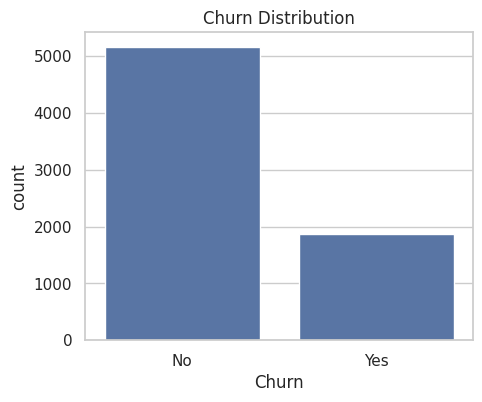

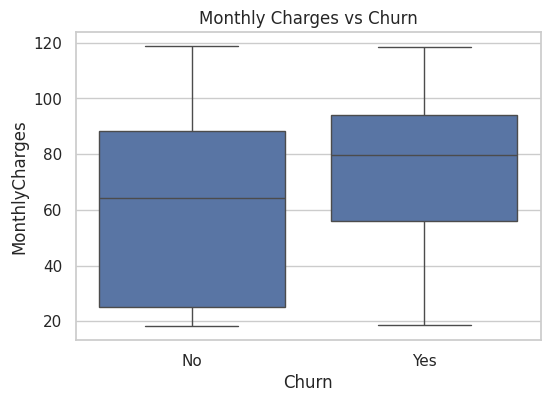

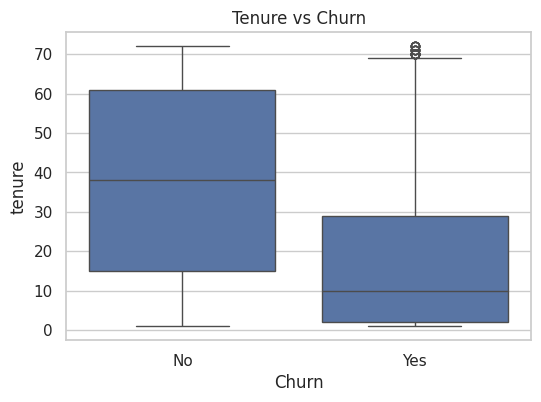

In [41]:
plt.figure(figsize=(5,4))
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title("Tenure vs Churn")
plt.show()

FEATURE ENGINEERING

In [42]:
df['tenure_group'] = pd.cut(
    df['tenure'],
    bins=[0,12,24,48,60,100],
    labels=['0-1yr','1-2yr','2-4yr','4-5yr','5+yr']
)

services = ['PhoneService','InternetService','OnlineSecurity',
            'OnlineBackup','DeviceProtection','TechSupport',
            'StreamingTV','StreamingMovies']

for col in services:
    if col in df.columns:
        df[col] = df[col].replace({'No internet service':'No',
                                   'No phone service':'No'})

df['num_services'] = (df[services] == 'Yes').sum(axis=1)

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group,num_services
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0-1yr,1
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,No,One year,No,Mailed check,56.95,1889.50,No,2-4yr,3
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,0-1yr,3
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,2-4yr,3
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,0-1yr,1


In [43]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group,num_services
0,0,0,1,0,1,0,1,0,0,1,...,0,0,0,1,2,29.85,29.85,0,0-1yr,1
1,1,0,0,0,34,1,0,0,1,0,...,0,0,1,0,3,56.95,1889.50,0,2-4yr,3
2,1,0,0,0,2,1,0,0,1,1,...,0,0,0,1,3,53.85,108.15,1,0-1yr,3
3,1,0,0,0,45,0,1,0,1,0,...,0,0,1,0,0,42.30,1840.75,0,2-4yr,3
4,0,0,0,0,2,1,0,1,0,0,...,0,0,0,1,2,70.70,151.65,1,0-1yr,1


##MODEL BUILDING

In [44]:
import pandas as pd
if 'tenure_group' in df.columns and isinstance(df['tenure_group'].dtype, pd.CategoricalDtype):
    le_tenure = LabelEncoder()
    df['tenure_group'] = le_tenure.fit_transform(df['tenure_group'])

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

##MODEL EVALUATION

L.R.

In [45]:
lr = LogisticRegression(class_weight='balanced', max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:,1]

print("Logistic Accuracy:", accuracy_score(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Accuracy: 0.738450604122246
ROC-AUC: 0.8299460063881225
              precision    recall  f1-score   support

           0       0.91      0.71      0.80      1033
           1       0.51      0.81      0.62       374

    accuracy                           0.74      1407
   macro avg       0.71      0.76      0.71      1407
weighted avg       0.80      0.74      0.75      1407



R.F.

In [46]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

print("RF Accuracy:", accuracy_score(y_test, y_pred_rf))
print("RF ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
print(classification_report(y_test, y_pred_rf))

RF Accuracy: 0.7604832977967306
RF ROC-AUC: 0.8305723944070279
              precision    recall  f1-score   support

           0       0.88      0.78      0.83      1033
           1       0.54      0.71      0.61       374

    accuracy                           0.76      1407
   macro avg       0.71      0.74      0.72      1407
weighted avg       0.79      0.76      0.77      1407



XGB

In [47]:
if xgb_available:
    xgb = XGBClassifier(
        eval_metric='logloss',
        use_label_encoder=False
    )

    xgb.fit(X_train, y_train)

    y_pred_xgb = xgb.predict(X_test)
    y_prob_xgb = xgb.predict_proba(X_test)[:,1]

    print("XGB Accuracy:", accuracy_score(y_test, y_pred_xgb))
    print("XGB ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [22:51:25] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGB Accuracy: 0.7704335465529495
XGB ROC-AUC: 0.8073416817224117


In [48]:
models = {
    "Logistic": roc_auc_score(y_test, y_prob_lr),
    "RandomForest": roc_auc_score(y_test, y_prob_rf)
}

if xgb_available:
    models["XGBoost"] = roc_auc_score(y_test, y_prob_xgb)

pd.Series(models).sort_values(ascending=False)

,0
RandomForest,0.830572
Logistic,0.829946
XGBoost,0.807342


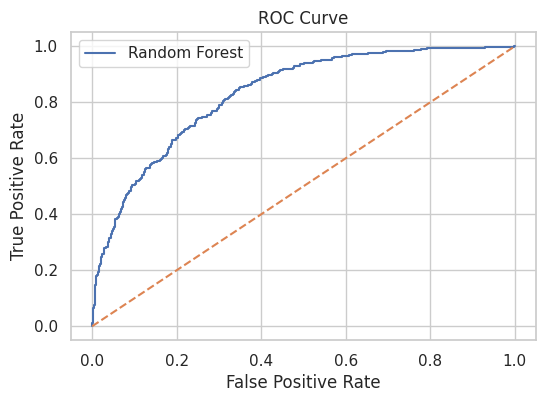

In [49]:
fpr, tpr, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label="Random Forest")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [50]:
importances = rf.feature_importances_

feature_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

feature_df.head(10)

,Feature,Importance
14,Contract,0.187561
4,tenure,0.149383
17,MonthlyCharges,0.141461
18,TotalCharges,0.121290
7,InternetService,0.076009
19,tenure_group,0.057227
16,PaymentMethod,0.043886
20,num_services,0.031227
8,OnlineSecurity,0.022716
15,PaperlessBilling,0.021593


BUSINESS INSIGHTS

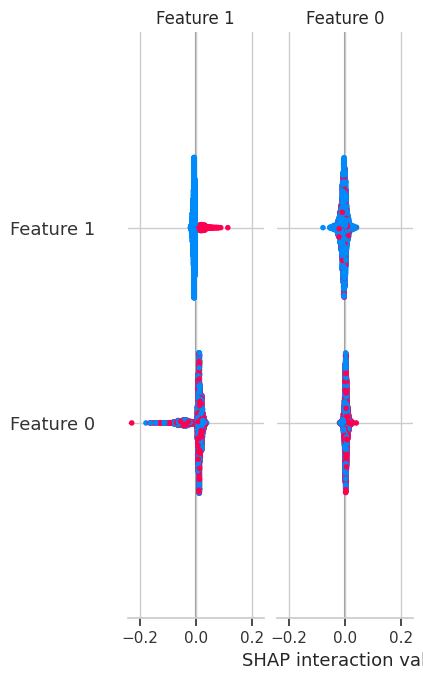

In [54]:
import shap

best_model = rf
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_train)

shap.summary_plot(shap_values, X_train)

FINANCIAL IMPACT SIMULATION

In [51]:
churned = df[df['Churn'] == 1]

avg_revenue = churned['MonthlyCharges'].mean()
monthly_loss = avg_revenue * len(churned)

print("Estimated Monthly Revenue Loss:", monthly_loss)

improved_retention = monthly_loss * 0.20

print("Potential Revenue Saved (20% Retention):", improved_retention)

Estimated Monthly Revenue Loss: 139130.85
Potential Revenue Saved (20% Retention): 27826.170000000002


##CONCLUSION

This project built an end-to-end machine learning system to predict telecom customer churn and identify key factors influencing customer behavior. The insights generated can help businesses take proactive retention measures and reduce potential revenue loss.